<h1 style="text-align:center;"><b>ECG Multi-Level Classification (PyTorch version)</b></h1>



# Dataset Download and Project Structure

(Unchanged from the original — see the TensorFlow notebook for the PhysioNet PTB-XL download instructions and folder layout.)

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import wfdb
import ast

from scipy.signal import butter, filtfilt, iirnotch
from sklearn.preprocessing import LabelEncoder

# One thing PyTorch doesn't auto-pick for you: the device.
# This checks for a GPU and falls back to CPU if there isn't one.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
print("PyTorch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA version: 12.8
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
import torch

print(torch.cuda.is_available())

True


In [4]:
print("PyTorch version:", torch.__version__)
print("CUDA version in PyTorch:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
CUDA version in PyTorch: 12.8
CUDA available: True


In [5]:
print(torch.version.cuda)

12.8


In [22]:
pip show torch

Name: torch
Version: 2.13.0
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License-Expression: Apache-2.0 AND Apache-2.0 WITH LLVM-exception AND BSD-2-Clause AND BSD-3-Clause AND BSL-1.0 AND MIT
Location: C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: executorch, torchvision
Note: you may need to restart the kernel to use updated packages.


Loading Metadata

In [7]:
print("Loading metadata...")

df = pd.read_csv(
    "data/ptbxl_database.csv",
    index_col="ecg_id"
)

df.scp_codes = df.scp_codes.apply(ast.literal_eval)

Loading metadata...


Load Diagnostic Mappings

In [8]:
scp_df = pd.read_csv(
    "data/scp_statements.csv",
    index_col=0
)

scp_df = scp_df[scp_df.diagnostic == 1]

<h2>Data Preprocessing</h2>

Convert SCP Codes to the 5 Superclasses

# ECG Diagnostic Classes

(Unchanged — see original notebook for the full clinical description of NORM, MI, STTC, CD, HYP.)

In [9]:
def aggregate_superclasses(code_dict):

    classes = []

    for key in code_dict.keys():   # If not working, remove .keys()

        if key in scp_df.index:

            c = scp_df.loc[key, "diagnostic_class"]

            if pd.notna(c):
                classes.append(c)

    return list(set(classes))

In [10]:
df["superclasses"] = (
    df.scp_codes.apply(aggregate_superclasses)
)

Keep only records containing at least one superclass

In [11]:
df = df[df.superclasses.apply(len) > 0]

print("Total usable ECGs:", len(df))

Total usable ECGs: 21396


<h3>Multi-Hot Encoding</h3>

In [12]:
# Define the classes
CLASSES = [
    "NORM",
    "MI",
    "STTC",
    "CD",
    "HYP"
]

# Create a mapping:
CLASS_TO_IDX = {
    c: i for i, c in enumerate(CLASSES)
}

In [13]:
# Multi-Hot encoding function

def encode_labels(labels):

    y = np.zeros(len(CLASSES), dtype=np.float32)

    for label in labels:

        if label in CLASS_TO_IDX:
            y[CLASS_TO_IDX[label]] = 1.0

    return y

# <span style="color:red">Important</span>

In [14]:
SELECTED_LEADS = [0]   ## IMPORTANT: Check which lead should be selected based on how we use the 3 electrodes in our module

<h3>FILTERING FUNCTIONS</h3>

In [15]:
def bandpass_filter(signal, fs=500):

    lowcut = 0.5
    highcut = 40.0

    nyquist = fs / 2

    b, a = butter(            # Butterworth filter (IIR)
        4,
        [lowcut / nyquist, highcut / nyquist],
        btype='band'
    )

    return filtfilt(b, a, signal, axis=0)

In [16]:
# Use only if necessary

def notch_filter(signal, fs=500):

    b, a = iirnotch(
        50,     # 50 Hz mains frequency
        30,     # Quality factor
        fs
    )

    return filtfilt(b, a, signal, axis=0)

<H3>Visualize one ECG before and after preprocessing</H3>

Labels: ['NORM']
[[-0.11 ]
 [-0.11 ]
 [-0.11 ]
 ...
 [-0.095]
 [-0.095]
 [-0.095]]


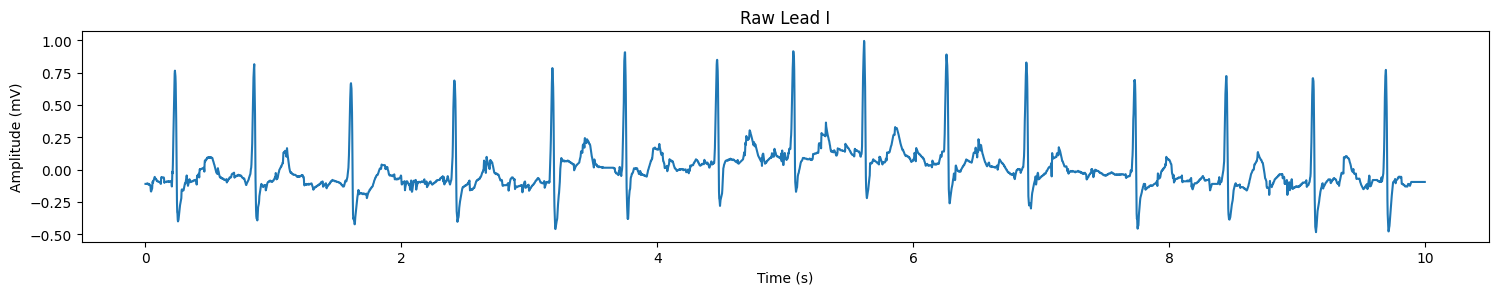

In [19]:
import matplotlib.pyplot as plt

sample_row = df.iloc[2000]

path = f"data/{sample_row.filename_hr}"

print("Labels:", sample_row.superclasses)

signal_raw, meta = wfdb.rdsamp(path)

# Select only the required leads
signal_raw = signal_raw[:, SELECTED_LEADS]

fs = 500
t = np.arange(signal_raw.shape[0]) / fs

lead_names = ["Lead I"]

# Plot raw ECG
plt.figure(figsize=(15, 8))

print(signal_raw)

for i in range(1):

    plt.subplot(3, 1, i + 1)

    plt.plot(t, signal_raw[:, i])

    plt.title(f"Raw {lead_names[i]}")

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (mV)")

plt.tight_layout()
plt.show()

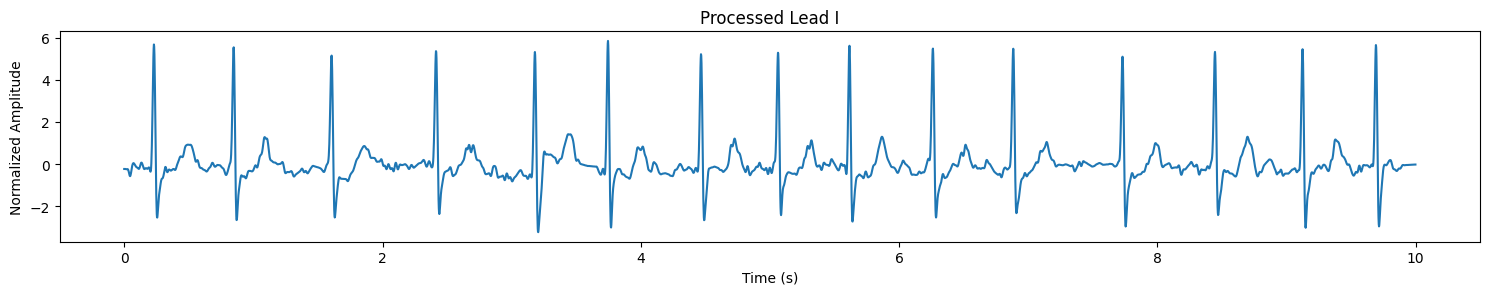

In [18]:
# After preprocessing

# Apply preprocessing manually
signal_processed = bandpass_filter(signal_raw)

signal_processed = notch_filter(signal_processed)

mean = signal_processed.mean(axis=0)
std = signal_processed.std(axis=0)

signal_processed = (signal_processed - mean) / std


# Plot processed ECG
plt.figure(figsize=(15, 8))

for i in range(1):

    plt.subplot(3, 1, i + 1)

    plt.plot(t, signal_processed[:, i])

    plt.title(f"Processed {lead_names[i]}")

    plt.xlabel("Time (s)")
    plt.ylabel("Normalized Amplitude")

plt.tight_layout()
plt.show()

<H3>ECG PREPROCESSING</H3>

In [16]:
def preprocess_ecg(path):

    signal, meta = wfdb.rdsamp(path)

    # Select only required leads
    signal = signal[:, SELECTED_LEADS]

    # Bandpass filtering
    signal = bandpass_filter(signal)

    # Notch filtering
    signal = notch_filter(signal)

    # Per-record z-score normalization
    mean = signal.mean(axis=0)
    std = signal.std(axis=0)

    std[std == 0] = 1e-8

    signal = (signal - mean) / std

    return signal.astype(np.float32)

<h4>DATASET CREATION</h4>

In [17]:
def build_dataset(dataframe):

    X = []
    Y = []

    total = len(dataframe)

    for idx, (_, row) in enumerate(dataframe.iterrows()):

        if idx % 500 == 0:
            print(f"{idx}/{total}")

        path = f"data/{row.filename_hr}"

        signal = preprocess_ecg(path)

        label = encode_labels(row.superclasses)

        X.append(signal)
        Y.append(label)

    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32)

    return X, Y

<h4>TRAIN / VALIDATION / TEST SPLITS</h4>

In [18]:
train_df = df[df.strat_fold <= 8]

val_df = df[df.strat_fold == 9]

test_df = df[df.strat_fold == 10]

print("\nTrain:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 17090
Validation: 2147
Test: 2159


<h3>Check Class Distribution</h3>

In [19]:
from collections import Counter

counter = Counter()

for labels in train_df["superclasses"]:
    counter.update(labels)

print("\nTraining Set Class Distribution")

for c in CLASSES:
    print(f"{c:5s}: {counter[c]}")


Training Set Class Distribution
NORM : 7598
MI   : 4381
STTC : 4188
CD   : 3909
HYP  : 2119


<h3>Compute class weights</h3>

In [20]:
total_samples = len(train_df)

class_weights = {}

print("\nClass Weights")

for c in CLASSES:

    weight = total_samples / (len(CLASSES) * counter[c])

    class_weights[c] = weight

    print(f"{c:5s}: {weight:.3f}")


Class Weights
NORM : 0.450
MI   : 0.780
STTC : 0.816
CD   : 0.874
HYP  : 1.613


In [21]:
# Convert to a PyTorch tensor
# (this is the only line that changes here: tf.constant -> torch.tensor,
# and we move it to whichever device we're training on)

CLASS_WEIGHT_VECTOR = torch.tensor(
    [class_weights[c] for c in CLASSES],
    dtype=torch.float32
).to(device)

print(CLASS_WEIGHT_VECTOR)

tensor([0.4499, 0.7802, 0.8161, 0.8744, 1.6130], device='cuda:0')


### Build Numpy arrays

In [22]:
print("\nBuilding training set...")
X_train, y_train = build_dataset(train_df)

print("\nBuilding validation set...")
X_val, y_val = build_dataset(val_df)

print("\nBuilding test set...")
X_test, y_test = build_dataset(test_df)


Building training set...
0/17090
500/17090
1000/17090
1500/17090
2000/17090
2500/17090
3000/17090
3500/17090
4000/17090
4500/17090
5000/17090
5500/17090
6000/17090
6500/17090
7000/17090
7500/17090
8000/17090
8500/17090
9000/17090
9500/17090
10000/17090
10500/17090
11000/17090
11500/17090
12000/17090
12500/17090
13000/17090
13500/17090
14000/17090
14500/17090
15000/17090
15500/17090
16000/17090
16500/17090
17000/17090

Building validation set...
0/2147
500/2147
1000/2147
1500/2147
2000/2147

Building test set...
0/2159
500/2159
1000/2159
1500/2159
2000/2159


In [23]:
# CHECK SHAPES

print("\nShapes:")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


Shapes:
X_train: (17090, 5000, 1)
y_train: (17090, 5)
X_val: (2147, 5000, 1)
y_val: (2147, 5)
X_test: (2159, 5000, 1)
y_test: (2159, 5)


# PyTorch Datasets & DataLoaders

**Why this section looks different from the TF version, explained simply:**

- `tf.data.Dataset` and PyTorch's `Dataset` + `DataLoader` do the same job (batching, shuffling,
  feeding data to the model) but PyTorch splits it into two pieces: a `Dataset` (knows how to fetch
  one sample) and a `DataLoader` (wraps it to produce shuffled batches).
- **Channel order matters.** Keras `Conv1D` expects shape `(batch, length, channels)` — "channels-last".
  PyTorch `Conv1d` expects `(batch, channels, length)` — "channels-first". Our `X_train` arrays come out
  of `build_dataset` as `(N, 5000, 1)` (length, channels), so we transpose to `(N, 1, 5000)` before
  handing them to the model. This is the single most common bug when porting TF conv code to PyTorch,
  so it's worth remembering.
- `.prefetch(tf.data.AUTOTUNE)` has no direct PyTorch equivalent to configure by hand — the DataLoader's
  `num_workers` argument (background worker processes that prepare the next batch while the GPU is busy)
  gives you the same speed-up.

In [38]:
class ECGDataset(Dataset):
    """
    Wraps the (N, 5000, 1) numpy arrays produced by build_dataset().
    Converts to PyTorch's channels-first convention: (N, 1, 5000).
    """
    def __init__(self, X, Y):
        # X: (N, 5000, 1) -> (N, 1, 5000)
        self.X = torch.from_numpy(X).permute(0, 2, 1).float()
        self.Y = torch.from_numpy(Y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


BATCH_SIZE = 32

train_dataset = ECGDataset(X_train, y_train)
val_dataset   = ECGDataset(X_val,   y_val)
test_dataset  = ECGDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("\nPreprocessing complete!")


Preprocessing complete!


<center><h1>ML Model Implementation</h1></center>

## Framework differences you'll notice from here on

Keras models in the original notebook are built **functionally**: you call `layers.Conv1D(...)(x)`
and chain tensors together, and `model.fit()` handles the entire training loop (forward pass, loss,
backward pass, optimizer step, logging, early stopping) for you.

PyTorch works differently in two ways that matter for the rest of this notebook:

1. **Models are Python classes.** You subclass `nn.Module`, define your layers in `__init__`, and
   define how data flows through them in a `forward()` method. There's no separate "layers.Input" —
   the input shape is just whatever you feed into `forward()`.
2. **There is no `.fit()`.** You write the training loop yourself: for each batch, run the model
   forward, compute the loss, call `loss.backward()` to get gradients, and `optimizer.step()` to
   update weights. This is more code, but it's *the same loop for every model in this notebook*, so
   we only have to write it once (see `train_model()` below) and reuse it for Models A, B, and C —
   mirroring `model.fit(...)` being called three times in the original.

## Custom weighted binary cross-entropy loss

**Use this loss function for all 3 models if the accuracy of the models are less due to the imbalance of the data set.**

In [25]:
def weighted_binary_crossentropy(y_pred_probs, y_true):
    """
    y_pred_probs: model output AFTER sigmoid, shape (batch, 5)
    y_true:       ground-truth multi-hot labels, shape (batch, 5)
    Equivalent to the Keras version: elementwise BCE, weighted per class,
    then averaged.
    """
    bce = F.binary_cross_entropy(y_pred_probs, y_true, reduction='none')
    return (bce * CLASS_WEIGHT_VECTOR).mean()

# Model Architectures

## Model A (ResNet-1D)

1D ResNets are a standard, heavily-used baseline for physiological signal classification (ECG, EEG, PPG).

Residual connections matter here because a plain deep CNN on a 5000-sample signal would suffer from vanishing gradients; skip connections fix that. This is a solid, fast baseline.

---

## Model B (ResNet + BiLSTM)

This is a well-known CNN-LSTM pattern: convolutional layers extract local morphological features (QRS shape, wave amplitudes), then the BiLSTM models how these features evolve and relate across time.

Useful for rhythm-based abnormalities that unfold over the full 10-second window rather than a single beat. This combination appears frequently in ECG arrhythmia literature.

---

## Model C (ResNet + Self-Attention)

Same ResNet stem, but a Transformer-style self-attention stack replaces the BiLSTM to model long-range temporal relationships.

<h1>Model A: ResNet</h1>

### Residual block, PyTorch style

Same architecture as the Keras version: `Conv1D(k=7) -> BN -> ReLU -> Conv1D(k=5) -> BN -> Add(shortcut) -> ReLU`,
with a 1x1 projection conv on the shortcut when the channel count changes.

Two PyTorch-specific things to know:
- `padding='same'` isn't available in `nn.Conv1d` for the odd kernel sizes here in the same automatic way
  Keras does it, so we pass `padding=kernel_size // 2` by hand, which is equivalent for odd kernel sizes.
- Every PyTorch layer that has learnable weights (Conv1d, BatchNorm1d, LSTM, Linear...) must be created
  inside `__init__` and *assigned to `self.something`* — that's how PyTorch discovers which tensors are
  trainable parameters. Contrast this with Keras where you just call `layers.Conv1D(...)` inline.

In [26]:
class ResidualBlock1D(nn.Module):
    """
    Conv1D(k=7) -> BN -> ReLU -> Conv1D(k=5) -> BN -> Add(shortcut) -> ReLU
    A 1x1 conv projects the shortcut when in_channels != out_channels.
    """
    def __init__(self, in_channels, out_channels, kernel_sizes=(7, 5)):
        super().__init__()
        k1, k2 = kernel_sizes

        self.conv1 = nn.Conv1d(in_channels, out_channels, k1, padding=k1 // 2)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, k2, padding=k2 // 2)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.project_shortcut = in_channels != out_channels
        if self.project_shortcut:
            self.shortcut_conv = nn.Conv1d(in_channels, out_channels, 1)
            self.shortcut_bn = nn.BatchNorm1d(out_channels)

    def forward(self, x):
        shortcut = x

        y = F.relu(self.bn1(self.conv1(x)))
        y = self.bn2(self.conv2(y))

        if self.project_shortcut:
            shortcut = self.shortcut_bn(self.shortcut_conv(shortcut))

        return F.relu(y + shortcut)


def make_residual_stage(in_channels, out_channels, n_blocks=2):
    """Stack `n_blocks` residual blocks. First block changes the channel count,
    the rest keep it fixed (in == out)."""
    blocks = [ResidualBlock1D(in_channels, out_channels)]
    for _ in range(n_blocks - 1):
        blocks.append(ResidualBlock1D(out_channels, out_channels))
    return nn.Sequential(*blocks)

Full Model

In [ ]:
class ResNet1D(nn.Module):
    def __init__(self, in_channels=1, num_classes=5):
        super().__init__()

        # Stem
        self.stem_conv = nn.Conv1d(in_channels, 64, kernel_size=15, stride=2, padding=7)
        self.stem_bn = nn.BatchNorm1d(64)

        # Stage 1: 64 channels
        self.stage1 = make_residual_stage(64, 64, n_blocks=2)
        self.pool1 = nn.MaxPool1d(2)

        # Stage 2: 128 channels
        self.stage2 = make_residual_stage(64, 128, n_blocks=2)
        self.pool2 = nn.MaxPool1d(2)

        # Stage 3: 256 channels
        self.stage3 = make_residual_stage(128, 256, n_blocks=2)
        self.pool3 = nn.MaxPool1d(2)

        # Stage 4: 512 channels
        self.stage4 = make_residual_stage(256, 512, n_blocks=2)

        # Head
        self.fc1 = nn.Linear(512, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc_out = nn.Linear(256, num_classes)

    def forward(self, x):
        # x: (batch, 1, 5000)
        x = F.relu(self.stem_bn(self.stem_conv(x)))

        x = self.stage1(x)
        x = self.pool1(x)

        x = self.stage2(x)
        x = self.pool2(x)

        x = self.stage3(x)
        x = self.pool3(x)

        x = self.stage4(x)

        # GlobalAveragePooling1D equivalent: mean over the length dimension
        x = x.mean(dim=2)          # (batch, 512)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc_out(x))   # sigmoid output, same as Keras version
        return x

<h4>Build the model</h4>

In [ ]:
NUM_CLASSES = 5

model_A = ResNet1D(in_channels=1, num_classes=NUM_CLASSES).to(device)

optimizer_A = torch.optim.Adam(model_A.parameters(), lr=1e-3)

loss_fn = F.binary_cross_entropy   # later swap to loss_fn = weighted_binary_crossentropy in case of an imbalance

Compile the model

**No PyTorch equivalent needed here.** Keras' `.compile()` bundles the optimizer, loss, and metrics
onto the model object. In PyTorch these three things just stay as separate Python variables
(`model_A`, `optimizer_A`, `loss_fn`) that you pass into the training loop yourself — nothing to
"compile". `model_A.summary()` also has no built-in equivalent; the closest thing is just printing
the model (`print(model_A)`), or installing the optional `torchinfo` package for a Keras-style summary
table.

In [ ]:
print(model_A)

# Optional: pip install torchinfo, then:
# from torchinfo import summary
# summary(model_A, input_size=(BATCH_SIZE, 1, 5000))

In [27]:
pip install torchinfo

Note: you may need to restart the kernel to use updated packages.


In [28]:
from torchinfo import summary
summary(model_A, input_size=(BATCH_SIZE, 1, 5000))

NameError: name 'model_A' is not defined

<h3>Train the model</h3>

**This is the biggest structural change from the TF notebook.** Keras' `model.fit(...)` hides the
training loop, early stopping, and LR scheduling inside one call. In PyTorch we write a small
reusable `train_model()` function that does the same three jobs `model.fit()` did:

1. Loop over epochs, and within each epoch loop over batches from the `DataLoader`.
2. Track `val_auc` (AUC on the validation set) each epoch, remember the best weights seen so far,
   and stop early if it hasn't improved in `patience` epochs — this replicates
   `EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True)`.
3. Use `torch.optim.lr_scheduler.ReduceLROnPlateau`, PyTorch's direct equivalent of Keras'
   `ReduceLROnPlateau` callback, watching `val_loss` with the same `factor=0.5, patience=4, min_lr=1e-6`.

We write this once and reuse it for Models A, B and C, exactly like `model.fit()` gets called three
times in the original notebook.

In [29]:
from sklearn.metrics import roc_auc_score

def run_epoch(model, loader, loss_fn, optimizer=None):
    """
    One pass over `loader`. If `optimizer` is given, this trains (backprop + weight update);
    if it's None, this only evaluates (used for validation/test).
    Returns: average loss, all true labels, all predicted probabilities.
    """
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    all_true, all_prob = [], []

    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            if is_training:
                optimizer.zero_grad()

            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            if is_training:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * X_batch.size(0)
            all_true.append(y_batch.detach().cpu().numpy())
            all_prob.append(y_pred.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    all_true = np.concatenate(all_true, axis=0)
    all_prob = np.concatenate(all_prob, axis=0)
    return avg_loss, all_true, all_prob


def train_model(model, train_loader, val_loader, optimizer, loss_fn,
                 epochs=50, patience=8, model_name="model"):
    """
    Mirrors Keras' model.fit(..., callbacks=[EarlyStopping(...), ReduceLROnPlateau(...)]).
    Monitors val AUC for early stopping (mode='max'), val loss for LR reduction.
    """
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=4, min_lr=1e-6
    )

    best_val_auc = -np.inf
    best_state = None
    epochs_without_improvement = 0
    history = {"loss": [], "val_loss": [], "val_auc": []}

    for epoch in range(1, epochs + 1):
        train_loss, _, _ = run_epoch(model, train_loader, loss_fn, optimizer)
        val_loss, val_true, val_prob = run_epoch(model, val_loader, loss_fn)

        # multi_label AUC, averaged across the 5 classes (same as Keras AUC(multi_label=True))
        try:
            val_auc = roc_auc_score(val_true, val_prob, average='macro')
        except ValueError:
            val_auc = float('nan')   # can happen early on if a class has no positives in val batch

        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auc"].append(val_auc)

        scheduler.step(val_loss)

        print(f"[{model_name}] Epoch {epoch:02d}/{epochs} "
              f"- loss: {train_loss:.4f} - val_loss: {val_loss:.4f} - val_auc: {val_auc:.4f}")

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch} (best val_auc={best_val_auc:.4f})")
                break

    # restore_best_weights=True equivalent
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [ ]:
EPOCHS = 50

history_A = train_model(
    model_A, train_loader, val_loader,
    optimizer_A, loss_fn,
    epochs=EPOCHS, patience=8, model_name="Model_A_ResNet"
)

<h1>Model B: ResNet + BiLSTM</h1>

The same Residual block above is used.

<h3>FULL MODEL: ResNet feature extractor + BiLSTM</h3>

**Note on `nn.LSTM` vs Keras `LSTM`:** PyTorch's `nn.LSTM` expects input shaped
`(batch, seq_len, features)` when `batch_first=True` — the same convention Keras uses, so no
transpose is needed here (only the *convolutional* layers needed the channels-first swap).
`bidirectional=True` is PyTorch's equivalent of wrapping a layer in `layers.Bidirectional(...)`.

In [ ]:
class ResNetBiLSTM(nn.Module):
    def __init__(self, in_channels=1, num_classes=5):
        super().__init__()

        # Stem -- downsamples 5000 -> 2500
        self.stem_conv = nn.Conv1d(in_channels, 64, kernel_size=15, stride=2, padding=7)
        self.stem_bn = nn.BatchNorm1d(64)

        # Stage 1: 64 channels, downsample 2500 -> 1250
        self.stage1 = make_residual_stage(64, 64, n_blocks=2)
        self.pool1 = nn.MaxPool1d(2)

        # Stage 2: 128 channels, downsample 1250 -> 625
        self.stage2 = make_residual_stage(64, 128, n_blocks=2)
        self.pool2 = nn.MaxPool1d(2)

        # Stage 3: 256 channels, downsample 625 -> 312
        self.stage3 = make_residual_stage(128, 256, n_blocks=2)
        self.pool3 = nn.MaxPool1d(2)

        # NOTE: stopping conv downsampling here (unlike pure ResNet which had
        # a 4th 512-channel stage) -- same rationale as the original: 312
        # timesteps is a reasonable length to feed a BiLSTM.

        # ---- BiLSTM over the extracted feature sequence ----
        self.lstm1 = nn.LSTM(input_size=256, hidden_size=128, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=64, batch_first=True, bidirectional=True)

        # ---- Classification head ----
        self.fc1 = nn.Linear(128, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x):
        # x: (batch, 1, 5000)
        x = F.relu(self.stem_bn(self.stem_conv(x)))

        x = self.stage1(x); x = self.pool1(x)
        x = self.stage2(x); x = self.pool2(x)
        x = self.stage3(x); x = self.pool3(x)
        # x: (batch, 256, 312) -- channels-first (conv convention)

        x = x.permute(0, 2, 1)   # -> (batch, 312, 256) -- sequence-first (LSTM convention)

        x, _ = self.lstm1(x)               # return_sequences=True equivalent: keep the full sequence
        x, (h_n, _) = self.lstm2(x)        # return_sequences=False equivalent: we only need the final state

        # h_n: (num_directions=2, batch, 64) for the last (2nd) LSTM layer.
        # Concatenate the forward and backward final hidden states, same as what
        # Keras' Bidirectional(..., return_sequences=False) returns.
        x = torch.cat([h_n[0], h_n[1]], dim=1)   # (batch, 128)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc_out(x))
        return x

<h3>Build the model</h3>

In [ ]:
NUM_CLASSES = 5

model_B = ResNetBiLSTM(in_channels=1, num_classes=NUM_CLASSES).to(device)

optimizer_B = torch.optim.Adam(model_B.parameters(), lr=1e-3)

loss_fn = F.binary_cross_entropy    # later swap to loss_fn = weighted_binary_crossentropy in case of an imbalance

<h3>Compile the model</h3>

(No `.compile()` step needed in PyTorch — see the note under Model A.)

In [ ]:
print(model_B)

In [ ]:
from torchinfo import summary
summary(model_B, input_size=(BATCH_SIZE, 1, 5000))

<h3>Train the model</h3>

In [ ]:
EPOCHS = 50

history_B = train_model(
    model_B, train_loader, val_loader,
    optimizer_B, loss_fn,
    epochs=EPOCHS, patience=8, model_name="Model_B_ResNet_BiLSTM"
)

<h1>Model C: ResNet + Self-Attention (No LSTM)</h1>

The same Residual block above is used.

<h3>POSITIONAL ENCODING (sinusoidal, as in the original Transformer)</h3>

In [30]:
def positional_encoding(seq_len, d_model, device=device):
    positions = np.arange(seq_len)[:, np.newaxis]
    dims = np.arange(d_model)[np.newaxis, :]

    angle_rates = 1 / np.power(10000, (2 * (dims // 2)) / np.float32(d_model))
    angle_rads = positions * angle_rates

    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    pe = torch.tensor(angle_rads[np.newaxis, ...], dtype=torch.float32)  # (1, seq_len, d_model)
    return pe.to(device)

<h3>TRANSFORMER-STYLE ENCODER BLOCK (self-attention + feed-forward)</h3>

**Note on `nn.MultiheadAttention`:** by default it expects `(seq_len, batch, features)`. We pass
`batch_first=True` at construction time so it matches Keras' `(batch, seq_len, features)` convention
and no extra transposing is needed here.

In [31]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads=4, ff_dim=256, dropout=0.1):
        super().__init__()
        self.mha = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads,
                                          dropout=dropout, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        self.ffn1 = nn.Linear(d_model, ff_dim)
        self.ffn2 = nn.Linear(ff_dim, d_model)
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x):
        # Multi-head self-attention with residual connection
        attn_out, _ = self.mha(x, x, x)   # query=x, key=x, value=x -> self-attention
        x = self.norm1(x + self.dropout1(attn_out))

        # Feed-forward network with residual connection
        ffn_out = self.ffn2(F.relu(self.ffn1(x)))
        x = self.norm2(x + self.dropout2(ffn_out))
        return x

<h3>FULL MODEL: ResNet feature extractor + Self-Attention</h3>

In [32]:
class ResNetAttention(nn.Module):
    def __init__(self, in_channels=1, num_classes=5,
                 d_model=256, num_heads=4, num_transformer_blocks=2):
        super().__init__()
        self.d_model = d_model

        # Stem -- downsamples 5000 -> 2500
        self.stem_conv = nn.Conv1d(in_channels, 64, kernel_size=15, stride=2, padding=7)
        self.stem_bn = nn.BatchNorm1d(64)

        # Stage 1: 64 channels, downsample 2500 -> 1250
        self.stage1 = make_residual_stage(64, 64, n_blocks=2)
        self.pool1 = nn.MaxPool1d(2)

        # Stage 2: 128 channels, downsample 1250 -> 625
        self.stage2 = make_residual_stage(64, 128, n_blocks=2)
        self.pool2 = nn.MaxPool1d(2)

        # Stage 3: 256 channels (= d_model), downsample 625 -> 312
        self.stage3 = make_residual_stage(128, 256, n_blocks=2)
        self.pool3 = nn.MaxPool1d(2)

        self.transformer_blocks = nn.ModuleList([
            TransformerEncoderBlock(d_model=d_model, num_heads=num_heads, ff_dim=512)
            for _ in range(num_transformer_blocks)
        ])

        self.fc1 = nn.Linear(d_model, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc_out = nn.Linear(128, num_classes)

        self._pe_cache = {}   # cache positional encodings per sequence length

    def forward(self, x):
        # x: (batch, 1, 5000)
        x = F.relu(self.stem_bn(self.stem_conv(x)))

        x = self.stage1(x); x = self.pool1(x)
        x = self.stage2(x); x = self.pool2(x)
        x = self.stage3(x); x = self.pool3(x)
        # x: (batch, 256, 312) -- channels-first (conv convention)

        x = x.permute(0, 2, 1)   # -> (batch, 312, 256) -- sequence-first (attention convention)
        seq_len = x.shape[1]

        if seq_len not in self._pe_cache:
            self._pe_cache[seq_len] = positional_encoding(seq_len, self.d_model, device=x.device)
        x = x + self._pe_cache[seq_len]

        for block in self.transformer_blocks:
            x = block(x)

        # GlobalAveragePooling1D equivalent: mean over the sequence dimension
        x = x.mean(dim=1)   # (batch, d_model)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc_out(x))     #x = self.fc_out(x)

        return x

<h3>Build the model</h3>

In [40]:
NUM_CLASSES = 5

model_C = ResNetAttention(in_channels=1, num_classes=NUM_CLASSES).to(device)

optimizer_C = torch.optim.Adam(model_C.parameters(), lr=1e-4)

loss_fn = F.binary_cross_entropy    # later swap to loss_fn = weighted_binary_crossentropy in case of an imbalance
# criterion = nn.BCEWithLogitsLoss(pos_weight=...)

<h3>Compile the model</h3>

(No `.compile()` step needed in PyTorch — see the note under Model A.)

In [34]:
print(model_C)

ResNetAttention(
  (stem_conv): Conv1d(1, 64, kernel_size=(15,), stride=(2,), padding=(7,))
  (stem_bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stage1): Sequential(
    (0): ResidualBlock1D(
      (conv1): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,))
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResidualBlock1D(
      (conv1): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,))
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (pool1): MaxPool1d(kernel_size=2, stride=2, paddi

In [35]:
from torchinfo import summary
summary(model_C, input_size=(BATCH_SIZE, 1, 5000))

Layer (type:depth-idx)                   Output Shape              Param #
ResNetAttention                          [32, 5]                   --
├─Conv1d: 1-1                            [32, 64, 2500]            1,024
├─BatchNorm1d: 1-2                       [32, 64, 2500]            128
├─Sequential: 1-3                        [32, 64, 2500]            --
│    └─ResidualBlock1D: 2-1              [32, 64, 2500]            --
│    │    └─Conv1d: 3-1                  [32, 64, 2500]            28,736
│    │    └─BatchNorm1d: 3-2             [32, 64, 2500]            128
│    │    └─Conv1d: 3-3                  [32, 64, 2500]            20,544
│    │    └─BatchNorm1d: 3-4             [32, 64, 2500]            128
│    └─ResidualBlock1D: 2-2              [32, 64, 2500]            --
│    │    └─Conv1d: 3-5                  [32, 64, 2500]            28,736
│    │    └─BatchNorm1d: 3-6             [32, 64, 2500]            128
│    │    └─Conv1d: 3-7                  [32, 64, 2500]           

<h3>Train the model</h3>

In [41]:
EPOCHS = 50

history_C = train_model(
    model_C, train_loader, val_loader,
    optimizer_C, loss_fn,
    epochs=EPOCHS, patience=8, model_name="Model_C_ResNet_Attention"
)

[Model_C_ResNet_Attention] Epoch 01/50 - loss: 0.4470 - val_loss: 0.3984 - val_auc: 0.8176
[Model_C_ResNet_Attention] Epoch 02/50 - loss: 0.4142 - val_loss: 0.3977 - val_auc: 0.8235
[Model_C_ResNet_Attention] Epoch 03/50 - loss: 0.4042 - val_loss: 0.3910 - val_auc: 0.8303
[Model_C_ResNet_Attention] Epoch 04/50 - loss: 0.3955 - val_loss: 0.3953 - val_auc: 0.8291
[Model_C_ResNet_Attention] Epoch 05/50 - loss: 0.3925 - val_loss: 0.3900 - val_auc: 0.8347
[Model_C_ResNet_Attention] Epoch 06/50 - loss: 0.3864 - val_loss: 0.3888 - val_auc: 0.8341
[Model_C_ResNet_Attention] Epoch 07/50 - loss: 0.3828 - val_loss: 0.3921 - val_auc: 0.8322
[Model_C_ResNet_Attention] Epoch 08/50 - loss: 0.3814 - val_loss: 0.3886 - val_auc: 0.8295
[Model_C_ResNet_Attention] Epoch 09/50 - loss: 0.3770 - val_loss: 0.3915 - val_auc: 0.8341
[Model_C_ResNet_Attention] Epoch 10/50 - loss: 0.3736 - val_loss: 0.3914 - val_auc: 0.8325
[Model_C_ResNet_Attention] Epoch 11/50 - loss: 0.3708 - val_loss: 0.3923 - val_auc: 0.8318

<h2>Thresholding sigmoid outputs to binary predictions</h2>

`model.predict(...)` doesn't exist in PyTorch — the equivalent is: set `model.eval()` (turns off
dropout/batch-norm training behaviour), wrap the forward pass in `torch.no_grad()` (skips building the
backward-pass graph, since we're not training), then call `model(X)` directly.

In [ ]:
THRESHOLD = 0.5
LABEL_NAMES = ["NORM", "MI", "STTC", "CD", "HYP"]

# Function to call on an entire data set
def get_predictions(model, loader, threshold=THRESHOLD):
    """
    Runs the model on a PyTorch DataLoader, returns:
    - y_true: ground-truth labels (N, 5)
    - y_prob: raw sigmoid outputs (N, 5)
    - y_pred: thresholded binary predictions (N, 5)
    """
    model.eval()
    y_true, y_prob = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch)
            y_prob.append(preds.cpu().numpy())
            y_true.append(y_batch.numpy())

    y_true = np.concatenate(y_true, axis=0)
    y_prob = np.concatenate(y_prob, axis=0)
    y_pred = (y_prob >= threshold).astype(int)

    return y_true, y_prob, y_pred


# Function to call on a single data (one ECG signal)
# NOTE: Model expects the input shape (batch_size, 1, 5000) -- channels-first
def predict_single(model, signal, label_names=LABEL_NAMES, threshold=THRESHOLD):
    """
    signal: raw ECG signal, shape (5000, 1) or (5000,)
    Returns: list of predicted label names, plus the raw probabilities
    """
    model.eval()

    signal = np.asarray(signal)
    if signal.ndim == 1:
        signal = signal.reshape(-1, 1)          # (5000,) -> (5000, 1)

    # (5000, 1) -> (1, 1, 5000): add batch dim, then permute to channels-first
    signal_batch = torch.from_numpy(signal).float().unsqueeze(0).permute(0, 2, 1).to(device)

    with torch.no_grad():
        y_prob = model(signal_batch).cpu().numpy()   # shape (1, 5)
    y_pred = (y_prob >= threshold).astype(int)         # shape (1, 5)

    y_prob = y_prob[0]      # shape (5,)
    y_pred = y_pred[0]      # shape (5,)

    predicted_labels = [label_names[i] for i in range(len(y_pred)) if y_pred[i] == 1]

    return predicted_labels, y_prob, y_pred


def final_output_on_single_data(predicted_labels):
    """Return the label as a string.
        If predicted_labels is empty => label = "UNKNOWN"
        If predicted_labels contains "NORM" + any other label => label = "UNKNOWN"
    Arg:
        predicted_labels (list): predicted label names, e.g. ['MI', 'NORM']
    Return:
        label (str): Label of the signal
    """
    if len(predicted_labels) == 0:
        label = "UNKNOWN"
    elif "NORM" in predicted_labels and len(predicted_labels) > 1:
        label = "UNKNOWN"
    else:
        label = ', '.join(predicted_labels)

    return label

<h2>Computing accuracy, precision, recall, F1</h2>

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, multilabel_confusion_matrix
)

In [ ]:
def evaluate_multilabel(y_true, y_pred, label_names=None, set_name=""):
    """
    Prints subset accuracy, Hamming accuracy, and micro/macro
    precision/recall/F1, plus per-label breakdown.
    (Unchanged from the TF notebook -- this operates on numpy arrays
    and never touched TensorFlow in the first place.)
    """
    n_labels = y_true.shape[1]
    if label_names is None:
        label_names = [f"Label_{i}" for i in range(n_labels)]

    subset_acc = accuracy_score(y_true, y_pred)
    hamming_acc = (y_true == y_pred).mean()

    precision_micro = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall_micro    = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1_micro        = f1_score(y_true, y_pred, average='micro', zero_division=0)

    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro    = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro        = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"\n{'='*60}")
    print(f"Evaluation on: {set_name}")
    print(f"{'='*60}")
    print(f"Subset Accuracy (exact match): {subset_acc:.4f}")
    print(f"Hamming Accuracy (per-label):  {hamming_acc:.4f}")
    print(f"\n--- Micro-averaged (pools all labels together) ---")
    print(f"Precision: {precision_micro:.4f}")
    print(f"Recall:    {recall_micro:.4f}")
    print(f"F1 Score:  {f1_micro:.4f}")
    print(f"\n--- Macro-averaged (unweighted mean across labels) ---")
    print(f"Precision: {precision_macro:.4f}")
    print(f"Recall:    {recall_macro:.4f}")
    print(f"F1 Score:  {f1_macro:.4f}")
    print(f"\n--- Per-label breakdown ---")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

    return {
        'subset_accuracy': subset_acc,
        'hamming_accuracy': hamming_acc,
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'f1_micro': f1_micro,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
    }

<h3>Running this across all three models and all three splits</h3>

In [ ]:
models_dict = {
    'Model_A_ResNet': model_A,
    'Model_B_ResNet_BiLSTM': model_B,
    'Model_C_ResNet_Attention': model_C,
}

loaders_dict = {
    'Train': train_loader,
    'Validation': val_loader,
    'Test': test_loader,
}

results = {}  # results[model_name][split_name] = metrics dict

for model_name, model in models_dict.items():
    results[model_name] = {}
    for split_name, loader in loaders_dict.items():
        y_true, y_prob, y_pred = get_predictions(model, loader)
        metrics_dict = evaluate_multilabel(
            y_true, y_pred,
            label_names=LABEL_NAMES,
            set_name=f"{model_name} — {split_name}"
        )
        results[model_name][split_name] = metrics_dict

<h3>Summary comparison table across models</h3>

In [ ]:
summary_rows = []
for model_name, splits in results.items():
    for split_name, metrics_dict in splits.items():
        row = {'Model': model_name, 'Split': split_name}
        row.update(metrics_dict)
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df[[
    'Model', 'Split', 'subset_accuracy', 'hamming_accuracy',
    'precision_micro', 'recall_micro', 'f1_micro',
    'precision_macro', 'recall_macro', 'f1_macro'
]]

print(summary_df.round(4).to_string(index=False))

## Evaluation Considerations

1. **Watch for train vs validation/test gaps**
   If any model scores near-perfect on the training set but performs noticeably worse on the validation/test set, it indicates **overfitting**. This should be reported alongside the raw performance numbers rather than considering only the test scores in isolation.

2. **Optimize classification thresholds instead of assuming 0.5**
   A threshold of **0.5** is not necessarily optimal, especially in the presence of class imbalance. If some of the 5 conditions are rare, a fixed threshold may result in poor recall for minority classes even when the model achieves a good raw AUC. Per-label thresholds can be tuned using **precision-recall curves on the validation set**.

3. **Saving/loading weights (bonus, PyTorch differs from Keras here)**
   Keras: `model.save("model.h5")` / `keras.models.load_model(...)`.
   PyTorch: `torch.save(model.state_dict(), "model_A.pt")` to save, and to reload you must first
   re-create the model class (e.g. `model_A = ResNet1D(); model_A.load_state_dict(torch.load("model_A.pt"))`) —
   PyTorch checkpoints only store the *weights*, not the architecture, so keep the class definitions handy.

<center><h1>Model Deployment</h1></center>

## Save the Models

In [53]:
torch.save(model_C.state_dict(), "Saved_Models/Model_C/ecg_resnet_attention.pth")

In [52]:
# Save the complete model

torch.save(model_C, "Saved_Models/Model_C/ecg_resnet_attention_complete.pth")

In [51]:
# Additional Informations

torch.save({
    'epoch': EPOCHS,
    'model_state_dict': model_C.state_dict(),
    'optimizer_state_dict': optimizer_C.state_dict(),
    'loss': loss_fn,
}, "Saved_Models/Model_C/ecg_resnet_attention_checkpoint.pth")

### Import for Mobile Application

In [64]:
pip install executorch

Note: you may need to restart the kernel to use updated packages.


In [65]:
from executorch.exir import to_edge_transform_and_lower
from executorch.backends.xnnpack.partition.xnnpack_partitioner import XnnpackPartitioner

model_C.cpu().eval()
example_inputs = (torch.randn(1, 1, 5000),)  # your real input shape

exported_program = torch.export.export(model_C, example_inputs)
program = to_edge_transform_and_lower(
    exported_program,
    partitioner=[XnnpackPartitioner()]  # CPU backend; swap for CoreMLPartitioner() on iOS
).to_executorch()

with open("Mobile_APP/Model_C/ecg_resnet_attention.pte", "wb") as f:
    f.write(program.buffer)

ImportError: cannot import name 'CustomInferenceAwareGraphPass' from 'torch._inductor.custom_graph_pass' (C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\_inductor\custom_graph_pass.py)

In [66]:
model_C.cpu()
model_C.eval()

example_input = torch.randn(1, 12, 1000)  # match your actual ECG input shape
traced_model = torch.jit.trace(model_C, example_input)
traced_model.save("Mobile_APP/Model_C/ecg_resnet_attention.pt")

RuntimeError: Given groups=1, weight of size [64, 1, 15], expected input[1, 12, 1000] to have 1 channels, but got 12 channels instead

In [62]:
# Run this if the above one is not working

model_C.cpu()
model_C.eval()
example_input = torch.randn(1, 1, 5000)

with torch.no_grad():
    traced_model = torch.jit.trace(model_C, example_input, check_trace=False)

traced_model.save("Mobile_APP/Model_C/ecg_resnet_attention.pt")

C:\Users\user\AppData\Local\Temp\ipykernel_11972\1374984500.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  positions = np.arange(seq_len)[:, np.newaxis]
C:\Users\user\AppData\Local\Temp\ipykernel_11972\1374984500.py:2: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  positions = np.arange(seq_len)[:, np.newaxis]
C:\Users\user\AppData\Local\Temp\ipykernel_11972\1374984500.py:2: TracerWarning: Converting a tensor to a Python float might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  positio

## Verify Correctness of the Imported Model

In [68]:
# Grab sample index 0 from the test set
x_sample, y_sample = test_dataset[0]   # x_sample: (1, 5000), y_sample: (5,) or however many classes

# Add batch dimension -> (1, 1, 5000)
example_input = x_sample.unsqueeze(0)

print(example_input.shape)   # torch.Size([1, 1, 5000])
print(y_sample)              # ground-truth label, useful for sanity-checking predictions

torch.Size([1, 1, 5000])
tensor([1., 0., 0., 0., 0.])


In [69]:
with torch.no_grad():
    orig_out = model_C(example_input)
    traced_out = traced_model(example_input)

print(torch.allclose(orig_out, traced_out, atol=1e-5))
print(orig_out, traced_out)

True
tensor([[0.7659, 0.0979, 0.0478, 0.1438, 0.0193]]) tensor([[0.7659, 0.0979, 0.0478, 0.1438, 0.0193]])


## Optimize the Imported Model

In [72]:
from torch.utils.mobile_optimizer import optimize_for_mobile

optimized_model = optimize_for_mobile(traced_model)
optimized_model._save_for_lite_interpreter("Mobile_APP/Model_C/ecg_resnet_attention_lite.ptl")

C:\Users\user\AppData\Local\Temp\ipykernel_11972\2445541016.py:4: DeprecationWarning: Lite Interpreter is deprecated. Please consider switching to ExecuTorch.             https://docs.pytorch.org/executorch/stable/getting-started.html
  optimized_model._save_for_lite_interpreter("Mobile_APP/Model_C/ecg_resnet_attention_lite.ptl")


In [74]:
# Verify correctness of the optimized model

with torch.no_grad():
    orig_out = model_C(example_input)
    optimized_out = optimized_model(example_input)

print("Match:", torch.allclose(orig_out, optimized_out, atol=1e-5))

Match: True
